## Генетический алгоритм

#### Постановка задачи

Вы являетесь разработчиком приложения для подсчета калорий (счетчик калорий).

Перед Вами поставили задачу добавления функции составления меню с учетом требований пользователя.

Требования пользователя можно представить в виде необходимого количества калорий и процент белков, жиров и углеводов в рационе.

Также есть БД с набором доступных для использования блюд.

Для представления БД используется словарь food.

In [1]:
def calc_calories(pfc: tuple[float, float, float]) -> float:
    return pfc[0] * 4 + pfc[1] * 9 + pfc[2] * 4

food = {
    "empty": (0, 0, 0),
    "творог": (16.0, 9.0, 3.0),
    "овсяна каша": (10.0, 6.0, 68.0),
    "мюсли": (7.5, 13.0, 62.0),
    "бутерброд с сыром": (12.8, 16.2, 29.6),
    "бутерброд с колбасой": (9.3, 13.3, 29.6),
    "торт": (4.8, 29.1, 54.3),
    "шашлык из свинины": (15.0, 17.8, 0.4),
    "банан": (1.5, 0.5, 21.0),
    "апельсин": (0.9, 0.2, 8.1),
    "яблоко": (0.4, 0.4, 9.8),
    "чай": (0.1, 0.0, 0.2),
}

food_keys = list(food.keys())
TEA = food_keys.index("чай")
EMPTY = food_keys.index("empty")

print("\n".join([f"{name}: {str(pfc)}" for name, pfc in food.items()]))

empty: (0, 0, 0)
творог: (16.0, 9.0, 3.0)
овсяна каша: (10.0, 6.0, 68.0)
мюсли: (7.5, 13.0, 62.0)
бутерброд с сыром: (12.8, 16.2, 29.6)
бутерброд с колбасой: (9.3, 13.3, 29.6)
торт: (4.8, 29.1, 54.3)
шашлык из свинины: (15.0, 17.8, 0.4)
банан: (1.5, 0.5, 21.0)
апельсин: (0.9, 0.2, 8.1)
яблоко: (0.4, 0.4, 9.8)
чай: (0.1, 0.0, 0.2)


#### Загрузка данных в DataFrame для эмуляции работы с БД

In [2]:
import pandas as pd

df = pd.DataFrame(columns=["name", "prt", "fat", "crb", "cal"])

for name, pfc in food.items():
    df.loc[len(df.index)] = [name, pfc[0], pfc[1], pfc[2], calc_calories(pfc)]

df

,name,prt,fat,crb,cal
0,empty,0.0,0.0,0.0,0.0
1,творог,16.0,9.0,3.0,157.0
2,овсяна каша,10.0,6.0,68.0,366.0
3,мюсли,7.5,13.0,62.0,395.0
4,бутерброд с сыром,12.8,16.2,29.6,315.4
5,бутерброд с колбасой,9.3,13.3,29.6,275.3
6,торт,4.8,29.1,54.3,498.3
7,шашлык из свинины,15.0,17.8,0.4,221.8
8,банан,1.5,0.5,21.0,94.5
9,апельсин,0.9,0.2,8.1,37.8


#### Проектирование вида хромосомы

Для решения поставленной задачи хромосома должна содержать перечень блюд.

Допустим, что максимальное количество блюд для одного приема пищи будет 4.

Таким образом, хромосома будет представлять собой массив (список) из четырех элементов.

Каждый элемент такого списка будет являться ссылкой на некоторое блюдо (первичный ключ таблицы Food из БД).

#### Функция для вывода хромосомы

Так как хромосома содержит ссылки на записи в таблице, требуется выводить вместо значения первичного ключа название блюда.

In [3]:
from typing import List

from pandas import DataFrame


def my_print(df:DataFrame, data: List[List[int]]) -> List[List[str]]:
    return [[str(df.loc[element]["name"]) for element in item] for item in data]

#### Функция для генерации начальной популяции

Данная функция генерирует популяцию из 30 особей, каждая особь представлена хромосомой.

Длина хромосомы 4 гена.

Каждый ген является ссылкой на блюдо.

Решение - это хромосома с оптимальным набором блюд.

Функция реализует самый простой способ генерации популяции - случайный выбор генов (дробовик).

Также функция позволяет задать в качестве значения последнего гена каждой хромосомы "чай".

Таким образом, данный пример показывает, что можно гибко настраивать процесс генерации популяции.

In [4]:
import numpy as np

POPULATION_COUNT = 30
GENE_SIZE = 4
SEED = 42
generator = np.random.default_rng(SEED)

def my_population(food: List[int], count: int, size: int, tea: bool = False) -> List[List[int]]:
    population: List[List[int]] = []
    while len(population) < count:
        element: List[int] = [-1] * size
        to = size
        if tea:
            element[-1] = TEA
            to = size - 1
        for position in range(to):
            value = generator.choice(range(len(food)))
            element[position] = food[value]
        population.append(element)
    return population

population = my_population(list(df.index.values), POPULATION_COUNT, GENE_SIZE, True)
display(len(population))
display(my_print(df, population))

30

[['творог', 'апельсин', 'шашлык из свинины', 'чай'],
 ['бутерброд с колбасой', 'бутерброд с колбасой', 'яблоко', 'чай'],
 ['творог', 'банан', 'овсяна каша', 'чай'],
 ['творог', 'торт', 'чай', 'чай'],
 ['банан', 'апельсин', 'банан', 'чай'],
 ['апельсин', 'торт', 'творог', 'чай'],
 ['яблоко', 'бутерброд с колбасой', 'торт', 'чай'],
 ['бутерброд с сыром', 'овсяна каша', 'чай', 'чай'],
 ['апельсин', 'шашлык из свинины', 'бутерброд с сыром', 'чай'],
 ['апельсин', 'торт', 'бутерброд с колбасой', 'чай'],
 ['бутерброд с колбасой', 'овсяна каша', 'творог', 'чай'],
 ['торт', 'яблоко', 'empty', 'чай'],
 ['яблоко', 'апельсин', 'мюсли', 'чай'],
 ['шашлык из свинины', 'творог', 'апельсин', 'чай'],
 ['банан', 'бутерброд с сыром', 'empty', 'чай'],
 ['чай', 'бутерброд с колбасой', 'яблоко', 'чай'],
 ['банан', 'апельсин', 'апельсин', 'чай'],
 ['овсяна каша', 'бутерброд с сыром', 'бутерброд с колбасой', 'чай'],
 ['бутерброд с колбасой', 'empty', 'торт', 'чай'],
 ['творог', 'банан', 'банан', 'чай'],
 ['ча

#### Фитнес функция

Работа фитнес функции основана на метода расчета калорий на основе показателей БЖУ и методе расчета процента БЖУ в рационе.

Описание методов доступно по ссылке https://www.sports.ru/health/blogs/3113398.html

В качестве ограничений используются переменный desired_calories, desired_protein_ratio, desired_fat_ratio, desired_carbon_ratio:
- количество калорий за прием пищи должен быть около 400;
- процент белка около 20 %;
- процент жира около 30 %;
- процент углеводов около 50%.

Для оценки решения на основе значения целевой функции для каждой хромосомы вычисляется общее количество калорий и процент БЖУ.

Затем вычисляется отклонение от ограничений для каждого параметра.

Значение фитнес функции является суммой всех отклонений.

Данная функция показывает, что фитнес функция может учитывать любые атрибуты анализируемого объекта (модель может быть любой).

При этом сама хромосома содержит лишь ссылки на объекты.

In [6]:
desired_calories = 400
desired_protein_ratio = 20
desired_fat_ratio = 30
desired_carbon_ratio = 50


def my_fitness(data: DataFrame, breakfast: List[int], debug: bool = False) -> float:
    food = data.loc[breakfast]

    total_calories = food["cal"].sum()
    total_protein = food["prt"].sum()
    total_fats = food["fat"].sum()
    total_carbones = food["crb"].sum()

    if total_calories == 0:
        return 1e9 

    protein_ratio = total_protein * 4 / total_calories * 100
    fat_ratio = total_fats * 9 / total_calories * 100
    carbon_ratio = total_carbones * 4 / total_calories * 100

    calories_diff = np.abs(total_calories - desired_calories)
    protein_diff = np.abs(protein_ratio - desired_protein_ratio)
    fat_diff = np.abs(fat_ratio - desired_fat_ratio)
    carbon_diff =  np.abs(carbon_ratio - desired_carbon_ratio)
    if debug:
        # текущие показатели
        display("Текущие КБЖУ:")
        display(f"cal = {total_calories}; p = {total_protein}; f = {total_fats}; c = {total_carbones}")
        display("Текущие КБЖУ в процентах:")
        display(
            f"cal = {total_calories:.2f}; prt_ratio = {protein_ratio:.2f} %; "
            f"ft_ratio = {fat_ratio:.2f} %; crb_ratio = {carbon_ratio:.2f} %"
        )
        # требования пользователя
        display("Требуемые КБЖУ:")
        display(
            f"cal_des = {desired_calories}; prt_des = {desired_protein_ratio}; "
            f"ft_des = {desired_fat_ratio}; crb_des = {desired_carbon_ratio}"
        )
        display("Разница:")
        display(
            f"cal_diff = {calories_diff:.2f}; prt_diff = {protein_diff:.2f}; "
            f"ft_diff = {fat_diff:.2f}; crb_diff = {carbon_diff:.2f}"
        )
        display("Значение фитнес функции:")

    return calories_diff + protein_diff + fat_diff + carbon_diff

# творог, банан, чай, пусто
display(my_fitness(df, [1, 8, TEA, EMPTY], True))

'Текущие КБЖУ:'

'cal = 252.7; p = 17.6; f = 9.5; c = 24.2'

'Текущие КБЖУ в процентах:'

'cal = 252.70; prt_ratio = 27.86 %; ft_ratio = 33.83 %; crb_ratio = 38.31 %'

'Требуемые КБЖУ:'

'cal_des = 400; prt_des = 20; ft_des = 30; crb_des = 50'

'Разница:'

'cal_diff = 147.30; prt_diff = 7.86; ft_diff = 3.83; crb_diff = 11.69'

'Значение фитнес функции:'

np.float64(170.68741590819155)

#### Оператор кроссинговера

В данном примере используется реализация простого (одноточечного) оператора кроссинговера.

Случайным образом определяется место разрыва хромосомы (номер гена), после чего правая часть первой хромосомы (гены) заменяется на правую часть второй хромосомы.

При реализации оператора кроссинговера можно учитывать различные ограничения: отсутствие повторяющихся генов, некоторый порядок генов и т. д.

In [12]:
generator = np.random.default_rng(SEED)

def my_crossover(item1: List[int], item2: List[int], size: int) -> List[int]:
    new_item = item1.copy()
    random_split_point = generator.choice(range(size - 1))
    new_item[random_split_point:] = item2[random_split_point:]
    return new_item

for _ in range(4):
    # творог, яблоко, апельсин, чай
    # шашлык, торт, пусто, чай
    display(my_print(df, [my_crossover([1, 10, 9, TEA], [7, 6, EMPTY, TEA], 4)]))

[['шашлык из свинины', 'торт', 'empty', 'чай']]

[['творог', 'яблоко', 'empty', 'чай']]

[['творог', 'торт', 'empty', 'чай']]

[['творог', 'торт', 'empty', 'чай']]

#### Оператор мутации

В данном примере используется одноточечный оператор мутации со случайным выбором.

Случайным образом определяется ген для мутации, который заменятся на случайное блюдо из доступных для выбора.

При реализации оператора мутации можно учитывать различные ограничения: отсутствие повторяющихся генов, некоторый порядок генов и т. д.

In [14]:
generator = np.random.default_rng(SEED)

def my_mutation(
    food: List[int], population: List[List[int]], size: int, proba: float = 1.0, debug: bool = False
) -> List[List[int]]:
    for element in range(len(population)):
        if generator.random(1)[0] > proba:
            continue
        position = generator.choice(range(size - 1))
        new_value = generator.choice(range(len(food)))
        if debug:
            display(f"e={element + 1}; p={position + 1}; v={new_value + 1}")
        population[element][position] = food[new_value]
    return population


display(my_print(df, my_mutation(list(df.index.values), population[:4], GENE_SIZE, debug=True)))

'e=1; p=2; v=6'

'e=2; p=1; v=9'

'e=3; p=2; v=12'

'e=4; p=3; v=10'

[['творог', 'бутерброд с колбасой', 'шашлык из свинины', 'чай'],
 ['банан', 'бутерброд с колбасой', 'яблоко', 'чай'],
 ['творог', 'чай', 'овсяна каша', 'чай'],
 ['творог', 'торт', 'апельсин', 'чай']]

#### Реализация простого ГА

Для реализации простого ГА используется библиотека PyGAD (Python Genetic Algorithm).

Документация доступна по ссылке https://pygad.readthedocs.io/en/latest/

PyGAD позволяет задать свои реализации функций и операторов ГА.

Также можно использовать функции и операторы из состава библиотеки.

Библиотека позволяет задать параметры для генерации популяции, определения структуры хромосомы, определения типа и диапазона допустимых значений для генов (min, max), вероятность мутации и кроссинговера и т. д.

Данный пример показывает возможность использования описанных ранее функций и операторов совместно с библиотекой PyGAD.

Для этого используются функции обертки (wrappers).

См. примеры по ссылкам:
- https://github.com/ahmedfgad/GeneticAlgorithmPython/blob/master/examples/example_custom_operators.py
- https://github.com/ahmedfgad/GeneticAlgorithmPython/blob/master/examples/example_fitness_wrapper.py

Результатом работы алгоритма является выбор оптимального решения задачи - три блюда + чай на завтрак с учетом ограничений.

/Users/user/Projects/python/mai-examples/lec4.2/.venv/lib/python3.13/site-packages/pygad/visualize/plot.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  matplt.legend()


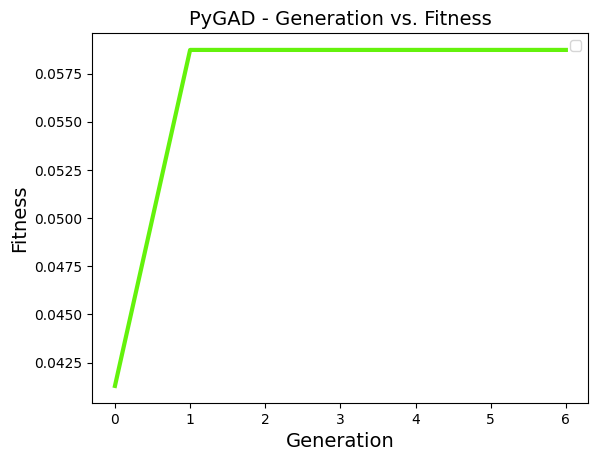

(array([10,  4,  9, 11]), np.float64(0.05872858447300955), np.int64(0))

[['банан', 'бутерброд с сыром', 'empty', 'чай'],
 ['яблоко', 'бутерброд с сыром', 'апельсин', 'чай'],
 ['яблоко', 'бутерброд с сыром', 'апельсин', 'чай'],
 ['яблоко', 'бутерброд с сыром', 'апельсин', 'чай'],
 ['яблоко', 'бутерброд с сыром', 'апельсин', 'чай'],
 ['яблоко', 'бутерброд с сыром', 'апельсин', 'чай'],
 ['яблоко', 'бутерброд с сыром', 'апельсин', 'чай']]

[['яблоко', 'бутерброд с сыром', 'апельсин', 'чай']]

'Текущие КБЖУ:'

'cal = 398.79999999999995; p = 14.200000000000001; f = 16.799999999999997; c = 47.70000000000001'

...

'cal_des = 400; prt_des = 20; ft_des = 30; crb_des = 50'

'Разница:'

'cal_diff = 1.20; prt_diff = 5.76; ft_diff = 7.91; crb_diff = 2.16'

'Значение фитнес функции:'

np.float64(17.02748244734206)

In [15]:
import pygad

generator = np.random.default_rng(SEED)

def fitness_func(ga_instanse: pygad.GA, solution: list, solution_idx: int) -> float:
    fitness_value = my_fitness(df, solution)
    return 1 / (fitness_value + 0.000001)


def parent_selection_func(fitness: np.ndarray, num_parents: int, ga_instance: pygad.GA) -> tuple:
    if ga_instance.population is None:
        raise ValueError("ga_instance.population is None")
    
    fitness_sorted = np.argsort(fitness)[::-1]    
    parents = ga_instance.population[fitness_sorted[:num_parents]].copy()
    return parents, np.array(fitness_sorted[:num_parents])


def crossover_func(parents: np.ndarray, offspring_size: list, ga_instance: pygad.GA) -> np.ndarray:
    offspring = []
    idx = 0
    proba = ga_instance.crossover_probability or 0.0
    while len(offspring) != offspring_size[0]:
        parent1 = parents[idx % parents.shape[0], :].copy()
        parent2 = parents[(idx + 1) % parents.shape[0], :].copy()
        if generator.random() > proba:
            offspring.append(parent1)
        else:
            result = my_crossover(parent1.tolist(), parent2.tolist(), GENE_SIZE)
            offspring.append(result)

        idx += 1
    return np.array(offspring)

def mutation_func(offspring: np.ndarray, ga_instance: pygad.GA) -> np.ndarray:
    proba = ga_instance.mutation_probability or 0.0
    mutated = my_mutation(list(df.index.values), offspring.tolist(), GENE_SIZE, proba)
    return np.array(mutated)

ga = pygad.GA(
    gene_type=int,
    num_generations=20,
    initial_population=population,
    num_parents_mating=int(POPULATION_COUNT * 0.3),
    fitness_func=fitness_func,
    parent_selection_type=parent_selection_func,  # type: ignore
    crossover_type=crossover_func,  # type: ignore
    crossover_probability=1.0,
    mutation_type=mutation_func,  # type: ignore
    mutation_probability=0.3,
    save_best_solutions=True,
    suppress_warnings=True,
    # Остановка, если значение фитнес функции лучшего решения не меняется 5 поколений подряд
    stop_criteria=["saturate_5"],
    # Параллельная обработка (8 потоков)
    parallel_processing=8,
    random_seed=SEED,
)

ga.run()
ga.plot_fitness()
display(ga.best_solution())

display(my_print(df, list(ga.best_solutions)))

my_breakfast = list(ga.best_solution()[0])
display(my_print(df, [my_breakfast]))
display(my_fitness(df, my_breakfast, True))

#### Анализ полученного решения

Лучшее найденное меню: ['яблоко', 'бутерброд с сыром', 'апельсин', 'чай'].

Его КБЖУ: cal = 398.79999999999995; prt = 14.200000000000001; ft = 16.799999999999997; crbn = 47.70000000000001

Отклонение от целевых значений: cal_diff = 1.20; prt_diff = 5.76; ft_diff = 7.91; crb_diff = 2.16

Почему это решение можно считать оптимальным:
- Оно максимально близко к целевым 400 ккал и пропорциям БЖУ.
- ГА сошёлся к этому решению уже на 2-м поколении, что свидетельствует о стабильности.

#### Использование на другом наборе данных

Для проверки адекватности разработанного ГА используем набор данных с необходимыми данными с Kaggle.

Ссылка на набор данных https://www.kaggle.com/datasets/niharika41298/nutrition-details-for-most-common-foods/data

Набор данных содержится в файле data/nutrients_csvfile.csv

Но набор данных был в не очень хорошем качестве, поэтому пришлось его предобработать (удалить строки для количественных признаков и заполнить пропуски нулями).

Предобработанный набор данных содержится в файле data/food.csv

Для использования набора данных в предложенном алгоритме были удалены отдельные признаки, а нужные признаки переименованы для соответствия модели данных.

Итоговый набор данных содержится в файле data/food-ga.csv

In [16]:
fooddf = pd.read_csv("data/food-ga.csv")

display(fooddf.info())
fooddf

<class 'pandas.DataFrame'>
RangeIndex: 335 entries, 0 to 334
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   name    335 non-null    str    
 1   prt     335 non-null    float64
 2   fat     335 non-null    float64
 3   crb     335 non-null    float64
 4   cal     335 non-null    float64
dtypes: float64(4), str(1)
memory usage: 13.2 KB


None

,name,prt,fat,crb,cal
0,Cows' milk,32.0,40.0,48.0,660.000
1,Milk skim,36.0,0.0,52.0,360.000
2,Buttermilk,9.0,5.0,13.0,127.000
3,"Evaporated, undiluted",16.0,20.0,24.0,345.000
4,Fortified milk,89.0,42.0,119.0,1.373
...,...,...,...,...,...
330,Fruit-flavored soda,0.0,0.0,42.0,161.000
331,Ginger ale,0.0,0.0,28.0,105.000
332,Root beer,0.0,0.0,35.0,140.000
333,Coffee,0.0,0.0,1.0,3.000


#### Создание популяции для нового набора данных

Используется та же функция, но для другого набора данных.

Размер новой популяции - 100 особей.

In [17]:
NEW_POPULATION_COUNT = 100

generator = np.random.default_rng(SEED)

new_population = my_population(list(fooddf.index.values), NEW_POPULATION_COUNT, GENE_SIZE)
display(len(new_population))
display(my_print(fooddf, new_population))

100

[['Butter', 'Waffles', 'Biscuits', 'Radishes'],
 ['Steamed potatoes before peeling', 'Marshmallows', 'Yolks', 'Flour'],
 ['Pork roast', 'Butter', 'Fresh, raw', 'Table (12.2% alcohol)'],
 ['Puffed wheat presweetened', 'whole-wheat', 'Oatmeal', 'Wheat, cooked'],
 ['Banana', 'Salt pork', 'Plain, with no icing', 'Spinach'],
 ['Dried, uncooked', 'Iceberg', 'Leg roasted', 'Tapioca cream pudding'],
 ['Wheat-germ cereal toasted', 'Strawberries', 'Frozen peas', 'Bread pudding'],
 ['Fruit cocktail, canned', 'Rutabagas', 'Spinach', 'Flounder'],
 ['Butter', 'Grapefruit juice', 'Molasses', 'Cheddar, grated cup'],
 ['Marshmallows', 'Chocolate fudge', 'Asparagus', 'Raisins'],
 ['chicken', 'of refined flour', 'Wheat (all purpose)', 'Endive'],
 ['Cream cheese', 'Wines', 'Soybeans', '9" diam. pie'],
 ['Cornflakes', 'Wheat germ', 'whole-wheat', 'Ham, as '],
 ['Lambs quarters, steamed', 'Raw, 2 by 2 1/2', 'Apricots', 'Ice cream'],
 ['Grapefruit sections',
  'Corned beef hash canned',
  'White',
  'Corn gr

#### Настройка гиперпараметров ГА

Обертки для вызова фитнес функции и оператора мутации были адаптированы для использования нового набора данных.

/Users/user/Projects/python/mai-examples/lec4.2/.venv/lib/python3.13/site-packages/pygad/visualize/plot.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  matplt.legend()


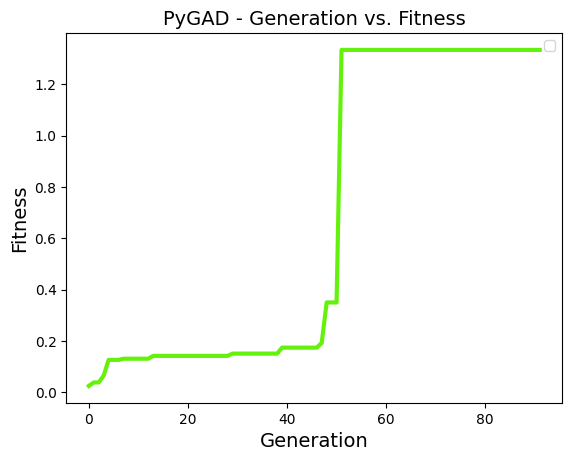

(array([283, 292, 115,  87]), np.float64(1.333331555557926), np.int64(0))

[['Puffed wheat presweetened', 'Rice flakes', 'Okra', 'Shad'],
 ['Candy', 'Rice flakes', 'Okra', 'Shad'],
 ['Candy', 'Rice flakes', 'Okra', 'Shad'],
 ['Brussels sprouts', 'Rice flakes', 'Rye', 'Shad'],
 ['Candy', 'Winter, mashed', 'Okra', 'Shad'],
 ['Candy', 'Winter, mashed', 'Okra', 'Shad'],
 ['Candy', 'Winter, mashed', 'Okra', 'Shad'],
 ['Candy', 'Rice flakes', 'Endive', 'Shad'],
 ['Candy', 'Rice flakes', 'Endive', 'Shad'],
 ['Candy', 'Rice flakes', 'Endive', 'Shad'],
 ['Candy', 'Rice flakes', 'Endive', 'Shad'],
 ['Candy', 'Rice flakes', 'Endive', 'Shad'],
 ['Candy', 'Rice flakes', 'Endive', 'Shad'],
 ['Candy', 'Rice flakes', 'Iceberg', 'Shad'],
 ['Candy', 'Rice flakes', 'Iceberg', 'Shad'],
 ['Candy', 'Rice flakes', 'Iceberg', 'Shad'],
 ['Candy', 'Rice flakes', 'Iceberg', 'Shad'],
 ['Candy', 'Rice flakes', 'Iceberg', 'Shad'],
 ['Candy', 'Rice flakes', 'Iceberg', 'Shad'],
 ['Candy', 'Rice flakes', 'Iceberg', 'Shad'],
 ['Candy', 'Rice flakes', 'Iceberg', 'Shad'],
 ['Candy', 'Rice flake

[['Candy', 'Honey', 'Cucumbers', 'Shad']]

'Текущие КБЖУ:'

'cal = 400.0; p = 20.0; f = 13.0; c = 50.0'

...

'cal_des = 400; prt_des = 20; ft_des = 30; crb_des = 50'

'Разница:'

'cal_diff = 0.00; prt_diff = 0.00; ft_diff = 0.75; crb_diff = 0.00'

'Значение фитнес функции:'

np.float64(0.75)

In [18]:
generator = np.random.default_rng(SEED)

def new_fitness_func(ga_instanse: pygad.GA, solution: list, solution_idx: int) -> float:
    fitness_value = my_fitness(fooddf, solution)
    return 1 / (fitness_value + 0.000001)


def new_mutation_func(offspring: np.ndarray, ga_instance: pygad.GA) -> np.ndarray:
    proba = ga_instance.mutation_probability or 0.0
    mutated = my_mutation(fooddf.index.values.tolist(), offspring.tolist(), GENE_SIZE, proba)
    return np.array(mutated)


new_ga = pygad.GA(
    gene_type=int,
    num_generations=300,
    initial_population=new_population,
    num_parents_mating=int(NEW_POPULATION_COUNT * 0.3),
    fitness_func=new_fitness_func,
    parent_selection_type=parent_selection_func,  # type: ignore
    crossover_type=crossover_func,  # type: ignore
    crossover_probability=1.0,
    mutation_type=new_mutation_func,  # type: ignore
    mutation_probability=0.5,
    save_best_solutions=True,
    suppress_warnings=True,
    stop_criteria=["saturate_40"],
    parallel_processing=8,
    random_seed=SEED,
)

new_ga.run()
new_ga.plot_fitness()
display(new_ga.best_solution())

display(my_print(fooddf, list(new_ga.best_solutions)))

my_new_breakfast = list(new_ga.best_solution()[0])
display(my_print(fooddf, [my_new_breakfast]))
display(my_fitness(fooddf, my_new_breakfast, True))

В результате работы ГА была сформирована следующая комбинация продуктов:
- Candy (конфеты или сладости) - продукт с высокой энергетической плотностью, выступающий основным источником быстрых углеводов.
- Honey (натуральный мед) - источник простых углеводов (глюкоза и фруктоза), обеспечивающий необходимую сладость и быстрое восполнение энергии.
- Cucumbers (свежие огурцы) - низкокалорийный овощ с высоким содержанием воды и клетчатки, который служит заглушкой для объема порции без значительного изменения калорийности.
- Shad (алоза, промысловая рыба семейства сельдевых) - важный источник полноценного животного белка и полезных жиров.

Алгоритм подобрал крайне странный, но математически точный рацион:
- рыба обеспечивает основу по белкам и жирам,
- мед и конфеты доводят уровень углеводов до целевой отметки в 50%,
- огурцы "закрывают" четвертый элемент меню, сохраняя общую калорийность на уровне 400 ккал.

Несмотря на необычность сочетания рыбы со сладостями и овощами, данный набор позволил достичь минимального суммарного отклонения (только 0.75 единицы по жирам) от требуемых КБЖУ.

#### Анализ влияния гиперпараметров на качество результата

В данной ячейке выполняется поиск по сетке (варьирование гиперпараметров) для ГА с целью получения минимального значения целевой функции

In [19]:
import time
from itertools import product

from tqdm.notebook import tqdm

results = []
num_generations = [20, 50, 100, 200, 300]
mutation_probs = [0.1, 0.3, 0.5, 0.6, 0.7, 0.8, 0.9]
pop_sizes = [20, 50, 100, 200, 500, 1000, 2000, 5000]

params = list(product(num_generations, mutation_probs, pop_sizes))

pbar = tqdm(params, desc="Grid Search", leave=False)

for num_generation, mut_prob, pop_size in pbar:
    pbar.set_postfix({"gen": num_generation, "mut": f"{mut_prob:.2f}", "pop": pop_size})

    # Сбрасываем ГСМ
    generator = np.random.default_rng(SEED)
    # Генерируем новую популяцию под размер
    pop = my_population(list(fooddf.index.values), pop_size, GENE_SIZE, True)
    ga_test = pygad.GA(
        gene_type=int,
        num_generations=num_generation,
        initial_population=pop,
        num_parents_mating=int(pop_size * 0.3),
        fitness_func=new_fitness_func,
        parent_selection_type=parent_selection_func,  # type: ignore
        crossover_type=crossover_func,  # type: ignore
        crossover_probability=1.0,
        mutation_type=new_mutation_func,  # type: ignore
        mutation_probability=mut_prob,
        save_best_solutions=True,
        suppress_warnings=True,
        # Остановка, если значение фитнес функции лучшего решения не меняется 15 % поколений подряд
        stop_criteria=[f"saturate_{max(int(num_generation * 0.15), 5)}"],
        parallel_processing=8,
        random_seed=SEED
    )

    # Засекаем время начала
    start_time = time.perf_counter()
    ga_test.run()

    # Вычисляем длительность и сохраняем лучшее решение
    duration = time.perf_counter() - start_time
    iteration_count = len(ga_test.best_solutions_fitness)
    best_food = my_new_breakfast = ga_test.best_solution()[0].tolist() # лучшая комбинация блюд
    best_fitness = ga_test.best_solutions_fitness[-1]  # значение фитнес функции последнего поколения
    results.append(
        {
            "num_generation": num_generation,
            "pop_size": pop_size,
            "mut_prob": mut_prob,
            "duration": duration,
            "iteration_count": iteration_count,
            "best_food": best_food,
            "best_fitness": best_fitness,
            "efficiency": best_fitness / np.log1p(duration),
        }
    )

Grid Search:   0%|          | 0/280 [00:00<?, ?it/s]

#### Результаты поиска по сетке

In [20]:
df_results = pd.DataFrame(results).sort_values(by=["best_fitness", "efficiency"], ascending=False)
display(df_results)

best_food = df_results.iloc[0]["best_food"]
best_food_fitness = my_fitness(fooddf, best_food, True)
display(my_print(fooddf, [best_food]))
display(best_food_fitness)
display(1 / (best_food_fitness + 0.000001))

,num_generation,pop_size,mut_prob,duration,iteration_count,best_food,best_fitness,efficiency
46,20,2000,0.8,9.438023,19,"[130, 141, 253, 11]",0.266667,0.113695
102,50,2000,0.8,10.515077,21,"[333, 141, 253, 11]",0.266667,0.109126
158,100,2000,0.8,14.423094,29,"[217, 141, 267, 11]",0.266667,0.097471
214,200,2000,0.8,21.803652,44,"[130, 141, 253, 11]",0.266667,0.085281
270,300,2000,0.8,29.490026,59,"[195, 36, 216, 11]",0.266667,0.078032
...,...,...,...,...,...,...,...,...
1,20,50,0.1,0.089815,13,"[273, 146, 287, 11]",0.034911,0.405903
8,20,20,0.3,0.029381,8,"[281, 150, 102, 11]",0.027165,0.938097
64,50,20,0.3,0.030805,10,"[281, 150, 102, 11]",0.027165,0.895354
24,20,20,0.6,0.032797,7,"[147, 254, 240, 11]",0.023926,0.741430


'Текущие КБЖУ:'

'cal = 400.0; p = 20.0; f = 13.0; c = 53.0'

'Текущие КБЖУ в процентах:'

'cal = 400.00; prt_ratio = 20.00 %; ft_ratio = 29.25 %; crb_ratio = 53.00 %'

...

'cal_diff = 0.00; prt_diff = 0.00; ft_diff = 0.75; crb_diff = 3.00'

'Значение фитнес функции:'

[['Parsley', 'French-fried', 'of refined flour', 'skim. milk']]

np.float64(3.75)

np.float64(0.2666665955555745)

Состав меню:
- French-fried (Картофель фри) — мощный источник углеводов и жиров. Видимо, ГА использовал его, чтобы быстро набрать калорийность, которой не хватало в других продуктах.
- Of refined flour (Из муки высшего сорта) — скорее всего, это какая-то выпечка, хлеб или блинчики. Основной источник углеводов.
- Skim milk (Обезжиренное молоко) — дает необходимый белок и кальций, но при этом почти не добавляет лишних жиров, что позволило алгоритму вписаться в норму по жирам (учитывая наличие картофеля фри).
- Parsley (Петрушка) — практически нулевая калорийность, она могла попасть в выборку как заглушка.

Суммарное отклонение от целевого КБЖУ составляет ровно 3.75 единицы.

Для генетического алгоритма это очень высокая точность - комбинация "жирного" картофеля и "пустого" молока позволила достигнуть поставленной цели.

#### Визуализация зависимости фитнес функции от гиперпараметров

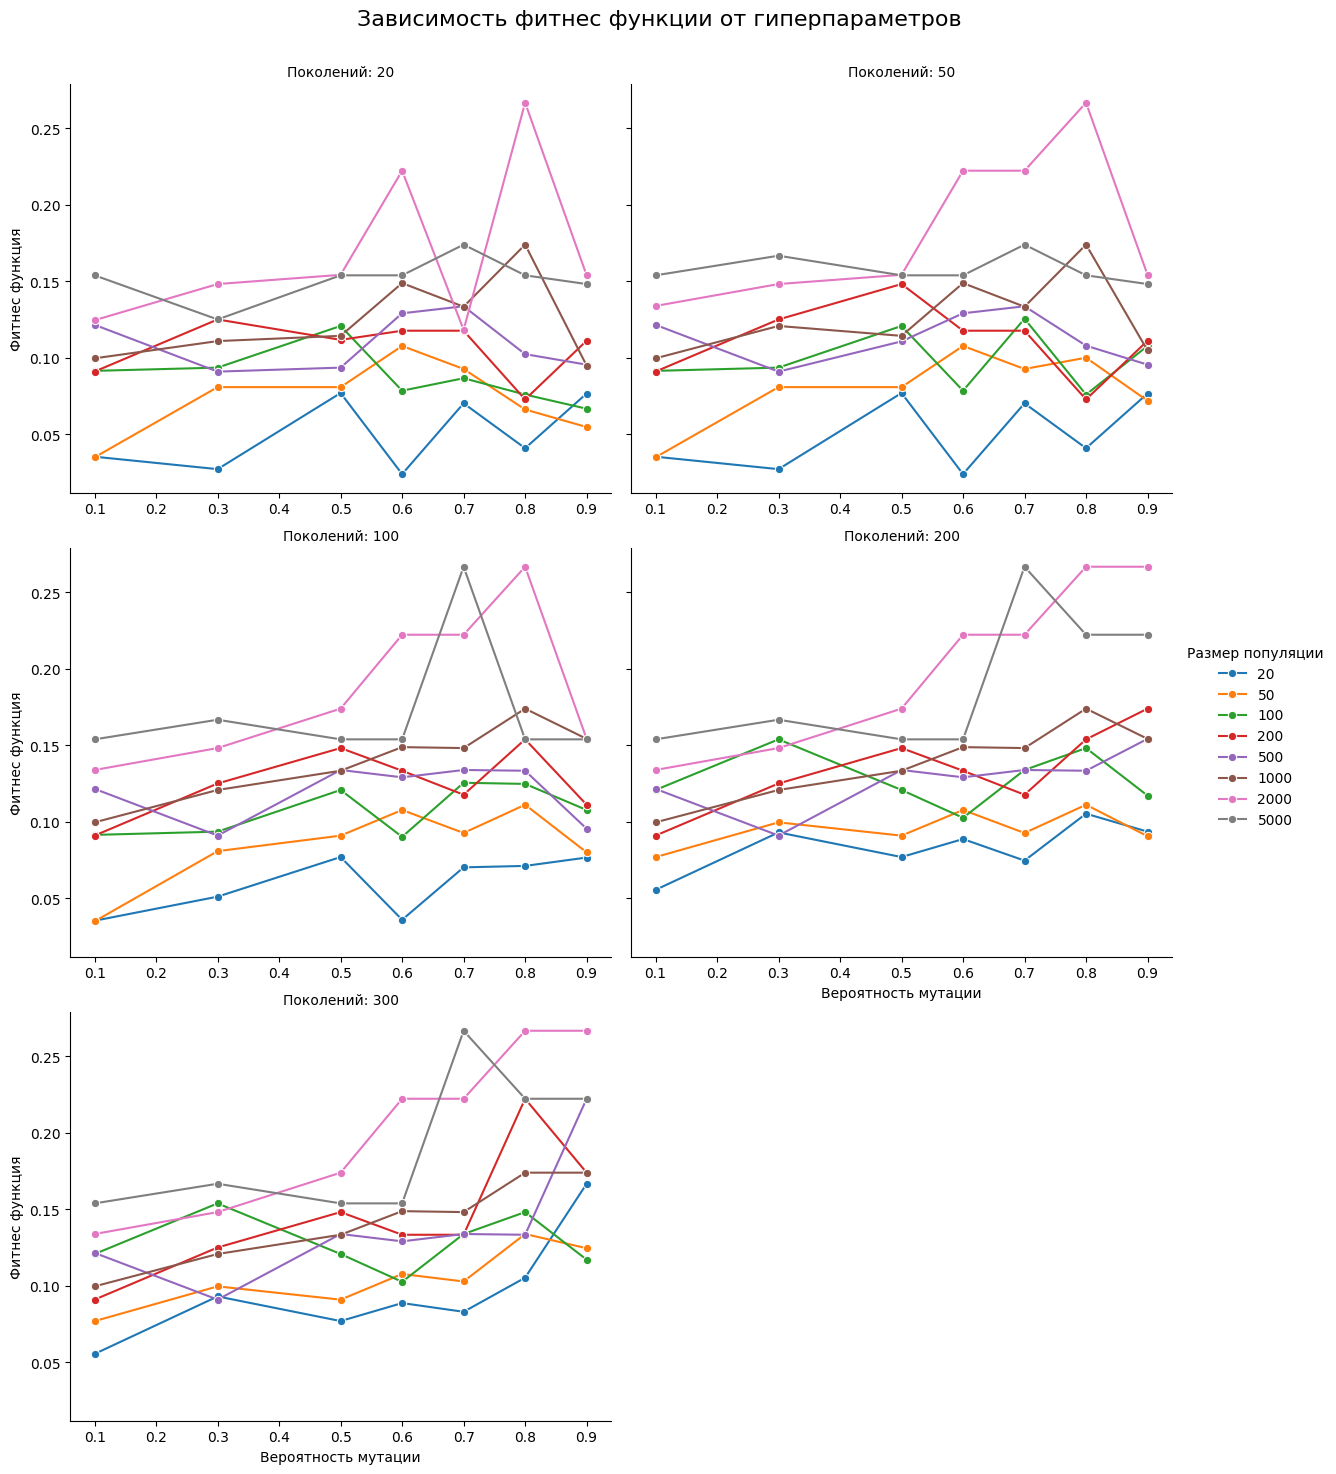

In [97]:
import seaborn as sns
from matplotlib import pyplot as plt

fc_grid = sns.FacetGrid(df_results, col="num_generation", hue="pop_size", col_wrap=2, height=5, aspect=1.2)
fc_grid.map(sns.lineplot, "mut_prob", "best_fitness", marker="o")
for ax in fc_grid.axes.flat:
    ax.tick_params(labelbottom=True)

fc_grid.add_legend(title="Размер популяции")
fc_grid.set_axis_labels("Вероятность мутации", "Фитнес функция")
fc_grid.set_titles("Поколений: {col_name}")
plt.subplots_adjust(top=0.93)
fc_grid.figure.suptitle("Зависимость фитнес функции от гиперпараметров", fontsize=16)

plt.show()

Гиперпараметры влияют на качество работы генетического алгоритма:
1. Решающую роль играет размера популяции.
    - Низкие значения (20–200 особей): синие, оранжевые и зеленые линии имеют значение фитнес функции < 0.15). Маленькой популяции просто не хватает "генетического разнообразия", чтобы найти хорошее решение без учета количества поколений.
    - Высокие значения (2000–5000 особей): розовая и серая линии стабильно доминируют, достигая пиковых значений фитнес функции (~0.27).
2. Влияние вероятности мутации:
    - Для крупных популяций лучшие результаты сосредоточены в диапазоне 0.6 – 0.8. Именно здесь графики показывают самые высокие пики.
    - При слишком низкой мутации (0.1–0.2) алгоритм быстро застревает в локальных минимумах.
    - При слишком высокой (0.9) процесс становится слишком хаотичным, и качество решения начинает изменять случайным образом.
3. Динамика по поколениям:
    - 20–50 поколений: алгоритм находит неплохие решения, но графики выглядят нестабильными.
    - 100–300 поколений: с ростом числа итераций линии графиков (особенно для больших популяций) становятся более сглаженными. Заметно, что после 200 поколений прирост фитнес функции замедляется. Это означает, что алгоритм близок к насыщению.
4. Лучшая комбинация гиперпараметров. Максимальное значение фитнес функции (при отклонении 3.75 от норма) достигается для 100, 200 и 300 поколений при:
    - Размере популяции: 5000 (розовая линия).
    - Вероятности мутации: 0.8.

Следовательно, необходимо использовать большую популяцию (от 2000) и агрессивную мутацию (0.7-0.8).

Увеличение количества поколений свыше 100 дает лишь небольшой эффект, так как лучшее решение можно найти раньше.

#### Комплексный анализ гиперпараметров

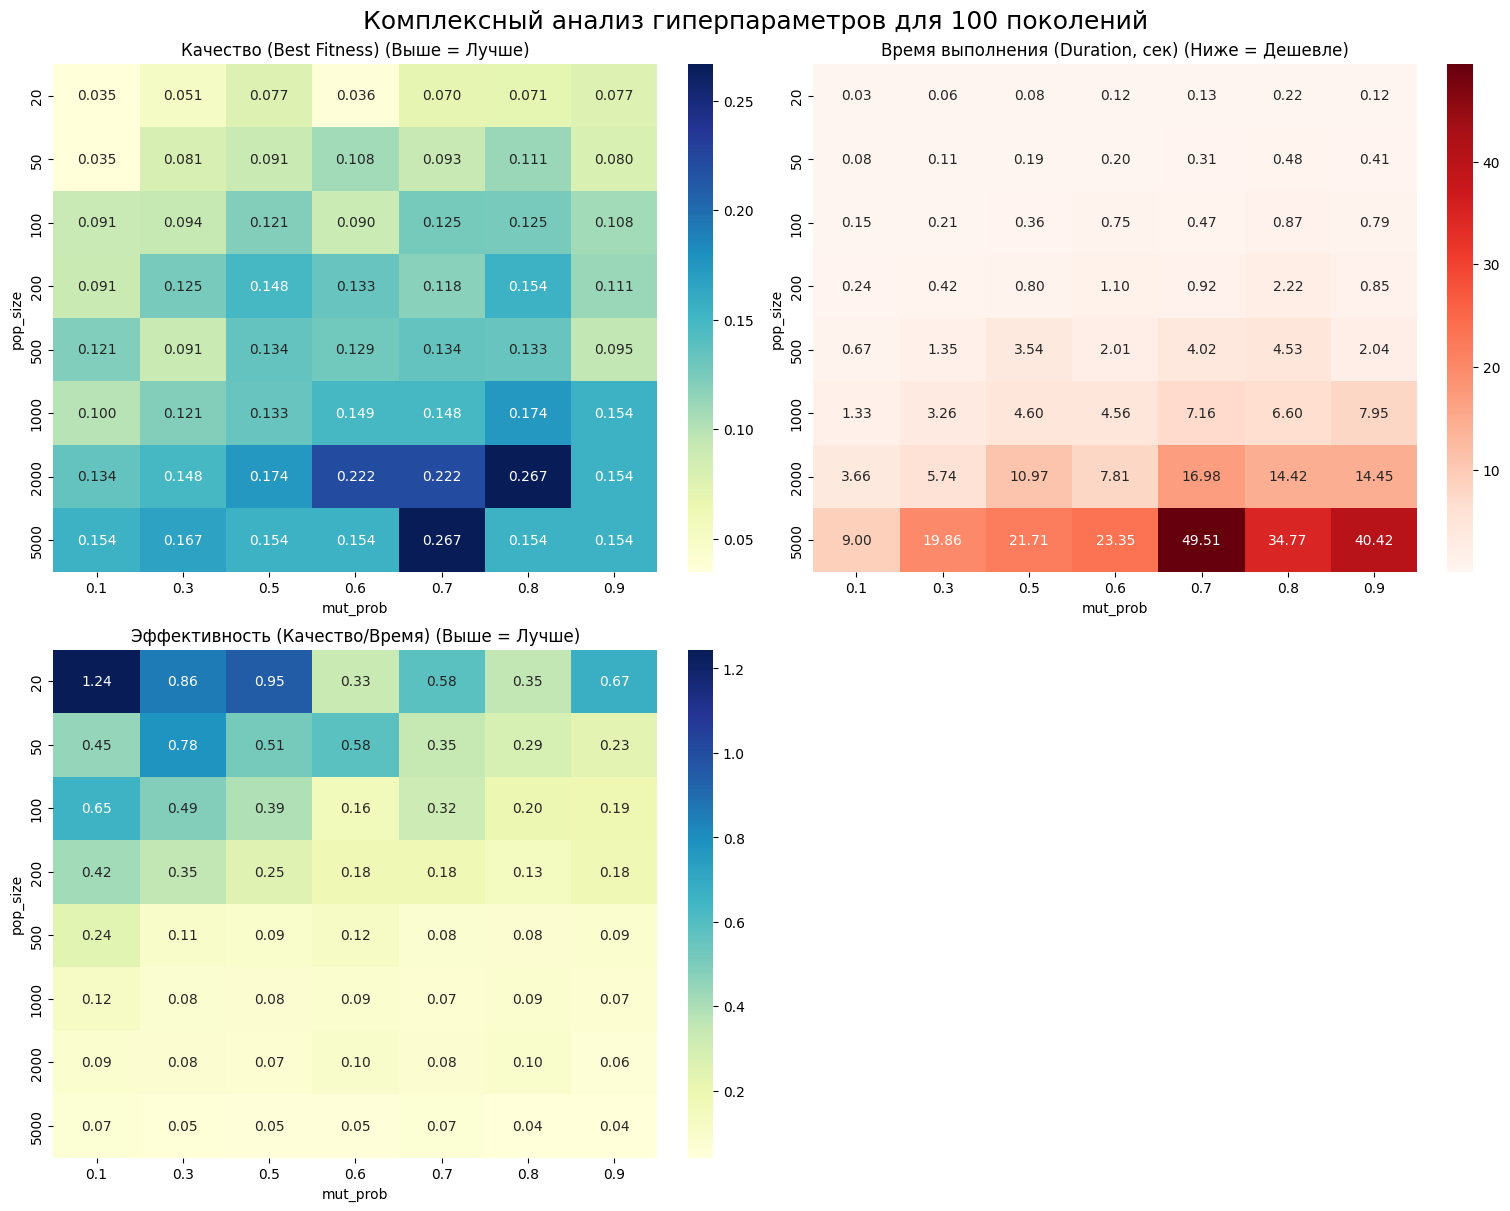

In [100]:
target_gen = df_results["num_generation"].median()
subset = df_results[df_results["num_generation"] == target_gen]

pivot_bf = subset.pivot(index="pop_size", columns="mut_prob", values="best_fitness")
pivot_eff = subset.pivot(index="pop_size", columns="mut_prob", values="efficiency")
pivot_time = subset.pivot(index="pop_size", columns="mut_prob", values="duration")

fig, axd = plt.subplot_mosaic([["A", "B"], ["C", "."]], figsize=(15, 12), constrained_layout=True)
sns.heatmap(pivot_bf, annot=True, cmap="YlGnBu", fmt=".3f", ax=axd["A"])
axd["A"].set_title("Качество (Best Fitness) (Выше = Лучше)")

sns.heatmap(pivot_time, annot=True, cmap="Reds", fmt=".2f", ax=axd["B"])
axd["B"].set_title("Время выполнения (Duration, сек) (Ниже = Дешевле)")

sns.heatmap(pivot_eff, annot=True, cmap="YlGnBu", fmt=".2f", ax=axd["C"])
axd["C"].set_title("Эффективность (Качество/Время) (Выше = Лучше)")

plt.suptitle(f"Комплексный анализ гиперпараметров для {int(target_gen)} поколений", fontsize=18)
plt.show()

На основе представленных тепловых карт (Heatmap) можно сделать следующие выводы о работе ГА для 100 поколений:
1. Качество (Best Fitness) (верхний левый график):
    - Прямая зависимость от размера популяции. Чем больше pop_size, тем выше значение фитнес функции. Лучшие результаты (темно-синяя зона) сосредоточены в нижней части графика при популяции 2000–5000.
    - Оптимальная мутация. При популяции 2000 пик качества достигается при mut_prob = 0.8 (фитнес 0.267). При слишком низкой (0.1) или слишком высокой (0.9) мутации качество заметно падает.
2. Время выполнения (Duration) (верхний правый график):
    - Экспоненциальный рост затрат. Время работы значительно растет при увеличении размера популяции. Если при pop_size = 20 расчет занимает 0.03 сек, то при pop_size = 5000 время достигает 49.51 сек.
    - Цена точности. Переход от популяции 2000 к 5000 увеличивает время в 3–4 раза, но практически не дает прироста в качестве.
3. Эффективность (Качество/Время) (нижний график):
    - Ловушка малых чисел. Самая высокая эффективность (1.24) зафиксирована при минимальной популяции (20) и мутации (0.1). Это происходит потому, что время выполнения ГА при таких параметрах минимальное, но качество такого решения низкое.
    - Если смотреть на зону с приемлемым качеством (фитнес > 0.15), то наиболее сбалансированным вариантом выглядит популяция 1000–2000 с мутацией 0.6–0.8. При таких параметрах эффективность еще не упала до минимума, а качество уже стабильно высокое.

Для рабочих запусков лучше всего использовать параметры pop_size = 2000 и mut_prob = 0.8. Это дает максимально возможное значение фитнес функции (0.267) за разумное время (около 14 секунд), в то время как дальнейшее увеличение популяции до 5000 только замедляет работу без улучшения результата.

#### Сравнение результата ГА со случайным перебором

In [80]:
import math

generator = np.random.default_rng(SEED)
num_random = 10000
# Считаем количество блюд в базе
n_foods = len(fooddf)
k_slots = 4
total_combinations = math.comb(n_foods + k_slots - 1, k_slots)

random_fitness = []
start_t = time.perf_counter()
for _ in range(num_random):
    rand_solution = [generator.choice(fooddf.index) for _ in range(4)]
    fit = my_fitness(fooddf, rand_solution)
    random_fitness.append(fit)
time_per_one = (time.perf_counter() - start_t) / num_random
total_time_seconds = total_combinations * time_per_one
days = total_time_seconds / (24 * 3600)

refited = 1 / df_results["best_fitness"].copy() - 0.000001

print(f"Среднее отклонение случайных меню: {np.mean(random_fitness):.2f}")
print(f"Медианное отклонение случайных меню: {np.median(random_fitness):.2f}")
print(f"Минимальное отклонение среди случайных: {np.min(random_fitness):.2f}")
print()

print(f"Среднее отклонение меню после ГА: {refited.mean():.2f}")
print(f"Медианное отклонение меню после ГА: {refited.median():.2f}")
print(f"Минимальное отклонение среди рещзультатов ГА: {refited.min():.2f}")
print()

print(f"Всего блюд в базе: {n_foods}")
print(f"Всего уникальных комбинаций: {total_combinations:,}")
print(f"Приблизительное время полного перебора: {days:.2f} дней")
ga_best_time = df_results[df_results["best_fitness"] == df_results["best_fitness"].max()]["duration"].min()
print(f"ГА нашел решение за: {ga_best_time:.2f} секунд")
print(f"Ускорение: {total_time_seconds / ga_best_time:,.0f} раз")

Среднее отклонение случайных меню: 404.93
Медианное отклонение случайных меню: 335.35
Минимальное отклонение среди случайных: 11.00

Среднее отклонение меню после ГА: 9.58
Медианное отклонение меню после ГА: 8.23
Минимальное отклонение среди рещзультатов ГА: 3.75

Всего блюд в базе: 335
Всего уникальных комбинаций: 534,219,140
Приблизительное время полного перебора: 1.41 дней
ГА нашел решение за: 9.44 секунд
Ускорение: 12,892 раз


#### Анализ полученного решения

Генетический алгоритм показал превосходство над случайным поиском:
- Из 10 000 случайных комбинаций лучшее отклонение составило 11.00, в то время как ГА нашел решение с отклонением всего 3.75.
- Случайный выбор: среднее отклонение — 404.93, медианное — 335.35.
- Результат ГА: среднее отклонение (по всем запускам Grid Search) — 9.58, медианное — 8.23.

Эффективность:
- Полный перебор всех комбинаций занял бы примерно 1.41 дня непрерывных вычислений.
- ГА нашел оптимальное решение за 9.44 секунды, что подтверждает применимость данного метода для задач составления рациона.

#### План улучшения генетического алгоритма для самостоятельной работы

Представленный ГА решает задачу подбора меню, но не учитывает совместимость блюд и предпочтения пользователя. Требуется его улучшение и расширение.

Ниже приведены возможные варианты для улучшения:
1. Модификация представления хромосом (кодирования решения):
    - Переменная длина хромосомы – разрешить разное количество блюд в меню (например, от 2 до 6). Это позволит находить более гибкие решения, но потребует изменения операторов кроссинговера и мутации.
    - Использование вещественных чисел – вместо индексов блюд кодировать, например, веса порций. Тогда каждое блюдо будет представлено не только фактом включения, но и количеством. Это приблизит задачу к реальности, но усложнит операторы.
    - Двухуровневое кодирование. Первый уровень – набор блюд, второй – их пропорции. Тогда поиск будет идти одновременно по составу и количеству.
2. Улучшение оператора кроссинговера:
    - Двухточечный и многоточечный кроссинговер. Сравнить с одноточечным, оценить влияние на разнообразие популяции.
    - Упорядоченный кроссинговер – полезен, если порядок блюд имеет значение (например, последовательность приема пищи). 
    - Кроссинговер с сохранением уникальности – запретить повторение одинаковых блюд в хромосоме (если это нежелательно). Для этого после скрещивания нужно удалять дубликаты или заменять их случайными блюдами.
3. Улучшение оператора мутации:
    - Инверсия – вместо замены одного гена разворачивать участок хромосомы. Это может быть полезно для задач, где важен порядок.
    - Направленная мутация – заменять блюдо на другое, близкое по питательным свойствам, чтобы улучшить значение фитнес (целевой) функции. Например, если не хватает белка, мутация может заменить низкобелковое блюдо на высокобелковое.
    - Адаптивная вероятность мутации – уменьшать вероятность мутации по мере сходимости алгоритма, чтобы не разрушать хорошие решения, или увеличивать вероятность мутации при стагнации (незначительное изменение значения фитнес функции).
4. Модификация фитнес-функции:
    - Учет нескольких целевых показателей – помимо калорий и БЖУ, добавить стоимость блюд, сезонность, личные предпочтения. Тогда фитнес функция станет многокритериальной. Можно использовать взвешенную сумму или методы Парето-оптимизации.
    - Штрафы за повторы. Штрафовать за дублирование блюд, чтобы меню было разнообразнее.
    - Штрафы за нежелательные ингредиенты – если пользователь не любит, например, рыбу, или у него на нее аллергия, то добавить большой штраф за блюда с рыбой.
    - Нелинейные преобразования – сделать фитнес более чувствительным к малым отклонениям или, наоборот, сгладить.
5. Улучшение стратегии отбора:
    - Турнирный отбор – заменить рулетку турнирным отбором (выбор нескольких особей случайно, лучшая из них становится родителем). Это часто дает лучшее разнообразие популяции.
    - Элитизм – гарантированно сохранять несколько лучших особей в следующем поколении. Это предотвращает потерю лучших решений. Исследовать оптимальное число элитных особей.
    - Отбор с усечением – отбирать только лучший процент популяции, остальных отбрасывать. Просто, но может привести к преждевременной сходимости.
6. Адаптация параметров:
    - Динамическое изменение размера популяции – начинать с популяции заданного размера, увеличивая или уменьшая ее при необходимости.
    - Адаптивная вероятность кроссинговера и мутации – изменять их в зависимости от разнообразия популяции или значения фитнес функции (например, если популяция однородна – увеличить мутацию).
    - Использование результатов grid search – на основе полученных данных выбрать наилучшие фиксированные гиперпараметры или определить зависимость качества решения и скорости работы алгоритма от гиперпараметров.
7. Параллельные и распределённые вычисления:
    - Островная модель – запустить несколько независимых популяций (островов) на разных ядрах/машинах и периодически обмениваться лучшими особями. Это ускоряет поиск и повышает разнообразие.
    - Параллельный расчет фитнес функции – если фитнес-функция сложная, вычислять её для всех особей параллельно (например, с помощью multiprocessing или Dask).
8. Гибридные методы:
    - Локальный поиск – после окончания ГА применять локальную оптимизацию (например, метод Хука-Дживса) для уточнения лучшего решения. Это помогает улучшить результат.
    - Комбинация с методами машинного обучения – использовать нейросеть для предсказания хороших начальных решений.
9. Анализ и визуализация:
    - Построение графиков разнообразия – отслеживать, как меняется разнообразие популяции (например, среднее расстояние между хромосомами) со временем. Это поможет диагностировать преждевременную сходимость.
    - Визуализация пространства решений – если возможно, показать на графике, где находятся лучшие решения относительно целевых показателей.
    - Сравнение с другими методами – случайный поиск, полный перебор (если возможно), жадные алгоритмы. Сравнить скорость и качество.
10. Расширение области применения:
    - Другие наборы данных – применить алгоритм к другой задаче: подбор тренировок, составление расписания, оптимизация портфеля и т.д. Потребуется адаптировать кодирование и фитнес.
    - Добавление динамических ограничений – например, изменяющиеся целевые показатели в зависимости от времени суток или активности пользователя.